# IB Motivo Locomotion Naming Model

In [1]:
# load model

import numpy as np
from numpy import matlib 

import matplotlib.pyplot as plt
from src import ib_naming_model
from src.tools import *

# ==> extra for plots
from scipy.stats import gaussian_kde
# for saving to mat
from scipy.io import loadmat, savemat

from skimage import color
import mediapy as media

from sklearn.manifold import MDS

BT = 0

# ==> IB model for feature...
# fdr = 'IB-qpos/'
fdr = 'IB-qpos-2D/'

# ==> directory (hard drive for resubmission with 1000 BTs) (COGSCI RESUBMISSION)
dr = '/home/thomas/Desktop/MIT-projects/meta-motivo-features/data/' + fdr
model_dr = '/home/thomas/Desktop/MIT-projects/meta-motivo-features/models/' + fdr

# # ==> data directory for COGSCI REVISION
# dr = '/media/thomas/U/cogsci-2025/eval-data/'

# ==> file --- BT0 is normal meaning space, BT0 are model for a randomly permuted meaning space
file = 'model_BT' + str(BT)  + '.pkl'

# ==> load gestures naming model
model = ib_naming_model.load_model(filename = file, model_dir = model_dr)

2025-07-05 16:33:42,263 [INFO] [ib_naming_model - load_model] loading model from file: /home/thomas/Desktop/MIT-projects/meta-motivo-features/models/IB-qpos-2D/model_BT0.pkl


(0.0, 1.824305378108003)

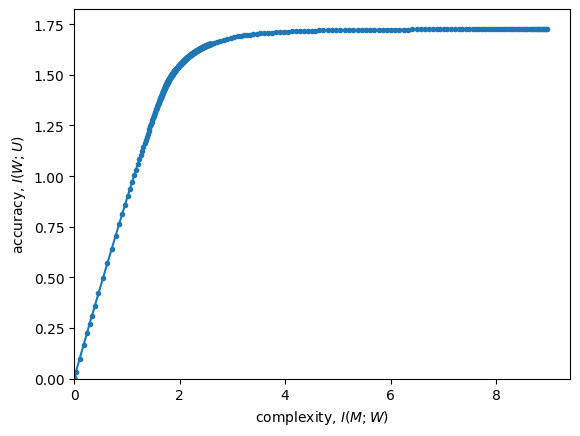

In [2]:
# plot the theoretical bound

curve = model.IB_curve

plt.plot(curve[0], curve[1],'.-')
plt.xlabel('complexity, $I(M;W)$')
plt.ylabel('accuracy, $I(W;U)$')
plt.xlim([0, H(model.pM)])
plt.ylim([0, model.I_MU + 0.1])

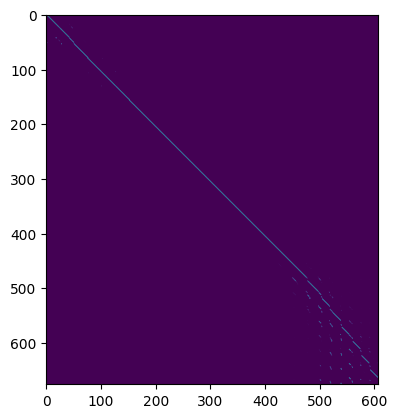

100000.0
(676, 607)


In [3]:
# ==> theoretical encoders
qW_M = model.qW_M
betas = model.betas

# ==> just choose one random example
ex = qW_M[-1]

# ==> show the example
plt.imshow(ex)
plt.show()
print(model.betas[-1])
print(ex.shape)

In [4]:
# ==> could do sanity check here

# ==> get fixed category q(w|m)s

# ==> compute IB_curve for fixed cat q(w|m)s

# ==> they should match model.IB_curve

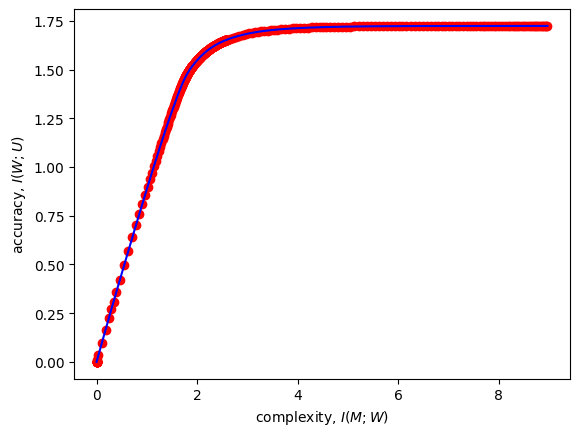

In [5]:
# sanity check...
fxc_Ix = np.zeros(len(model.betas))
fxc_Iy = np.zeros(len(model.betas))
for i in range(len(model.betas)):
    fxc_Ix[i] = model.complexity(qW_M[i])
    fxc_Iy[i] = model.accuracy(qW_M[i])

plt.plot(fxc_Ix,fxc_Iy,'ro')
plt.plot(curve[0], curve[1],'b')
plt.xlabel('complexity, $I(M;W)$')
plt.ylabel('accuracy, $I(W;U)$')
plt.show()

# ==> set IB curve values to the ones computed from fix_cats q(w|m)
curve = (fxc_Ix, fxc_Iy)

In [6]:
# ==> parameters associated with mosaic...

reso = 26 #6 
# ==> alphas for interpolation
alphas = np.linspace(0.0,1.0,reso)
alphas = alphas[::-1]

# ==> read labels, mds proj etc
# ...

# ...

# ...


In [7]:
drc = '/home/thomas/Desktop/MIT-projects/meta-motivo-stim/ex11/'


def arr_creat(upperleft, upperright, lowerleft, lowerright):
    arr = np.linspace(np.linspace(lowerleft, lowerright, arrwidth), 
                      np.linspace(upperleft, upperright, arrwidth), arrheight, dtype=int)
    return arr[:, :, None]

# ==> color visualization option
COLOR = True 
# COLOR = False

# frame dimensions
height = 30
width  = 40
# ~~~~~~~~~~~~ SKIP T-POSE FRAMES APPROX ~~~~~~~~~~~~ #
skip = 0

frames_all_j = []

rw = 0
reso = 26
# ==> alphas for interpolation
alphas = np.linspace(0.0,1.0,reso)
alphas = alphas[::-1]
rngi = range(0,len(alphas))
rngj = range(0,len(alphas))

arrwidth = len(alphas)
arrheight = len(alphas)
r = arr_creat(0,   255, 0,   255)
g = arr_creat(0,   0,   255, 0)
b = arr_creat(255, 255, 0,   0)
cmask = np.concatenate([r, g, b], axis=2)

# ==> cmask should change based on posterior (inverse encoder)

# ************************************
# ==> theoretical encoders
beta_n = len(betas) - 375
# ==> q(w|m)
qW_M = model.qW_M
# ==> just choose one random example
qwm = qW_M[beta_n]
qmw = model.po(qwm)
qmw = qmw.T
# ************************************

# ==> list of file names
names = []
# ==> track RGB colors for visualization
rgb  = np.zeros((len(alphas)**2,3))

k = 0
for i in rngi:
    #frames_all_i = []
    for j in rngj:
        # ==> load video frames
        frames = np.load(drc + 'z_matrices/' + 'frames-'  + str(i) + '-' + str(j) +  '.npy')
        # ==> file names (mp4)
        names.append('video-' + str(i) + '-' + str(j) + '.mp4')
        # ==> colors for vis
        rgb[k,:] = cmask[i,j,:]
        # ==> increment counter
        k += 1

# ==> posterior weighted color mask
cm = np.zeros((qmw.shape[0],qmw.shape[1],3))
# ==> partition
for p in range(qmw.shape[1]):
    # rgb values multiplied by posterior probabilities for partition p
    c = qmw[:,p] * rgb.T

    # ==> ???????????????????????????????????????????????????????????????????????????????????????
    rgbm = np.sum(c,1)/np.sum(c)  * np.ones((1,3)) * 255
    rgbm = matlib.repmat(rgbm, qmw.shape[0], 1)
    # ==> ???????????????????????????????????????????????????????????????????????????????????????
    
    # add rgb values
    cm[:,p,:] = rgbm #c.T

# # ==> partition - get column index of max probability in q(m|w)
# rgb_idx_p = np.argmax(qmw,1)
# # ==> reshape color matrix cm in partition corresponding to max probability in q(m|w)
# cm_p = np.reshape(np.squeeze(cm[:,rgb_idx_p[k],:]),(26,26,3))

k = 0
for i in rngi:
    #frames_all_i = []
    for j in rngj:
        
        frames = np.load(drc + 'z_matrices/' + 'frames-'  + str(i) + '-' + str(j) +  '.npy')
        
        # ==> add color to frames
        if COLOR:
            for fr in range(frames.shape[0]):
                # ==> partition - get column index of max probability in q(m|w)
                rgb_idx_p = np.argmax(qmw,1)
                # ==> reshape color matrix cm in partition corresponding to max probability in q(m|w)
                cm_p = np.reshape(np.squeeze(cm[:,rgb_idx_p[k],:]),(26,26,3))

                # ==> color the video frames for video (i,j) in mosaic with color corresponding to partition
                frames[fr,:,:,:] =  frames[fr,:,:,:] * cm_p[i,j,:]/255 #frames[fr,:,:,:] * cm[i,j,:]/255
                
        # ==> downsample
        frames = media.resize_video(frames[skip::],(height,width))
        # ==> stack frames into a mosaic
        if j == min(rngj):
            frames_all_i = frames
        else:
            frames_all_i = np.concatenate((frames_all_i, frames),2)

        # ==> increment
        k += 1
    
    if i == min(rngi):
        frames_all_j = frames_all_i
    else:
        frames_all_j = np.concatenate((frames_all_j, frames_all_i),1)
print('done')

# ==> show
media.show_video(frames_all_j, fps=30)

done


This browser does not support the video tag.


/tmp/ipykernel_11867/2756817278.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(proj[k,0],proj[k,1], c=clrs[k]/255)


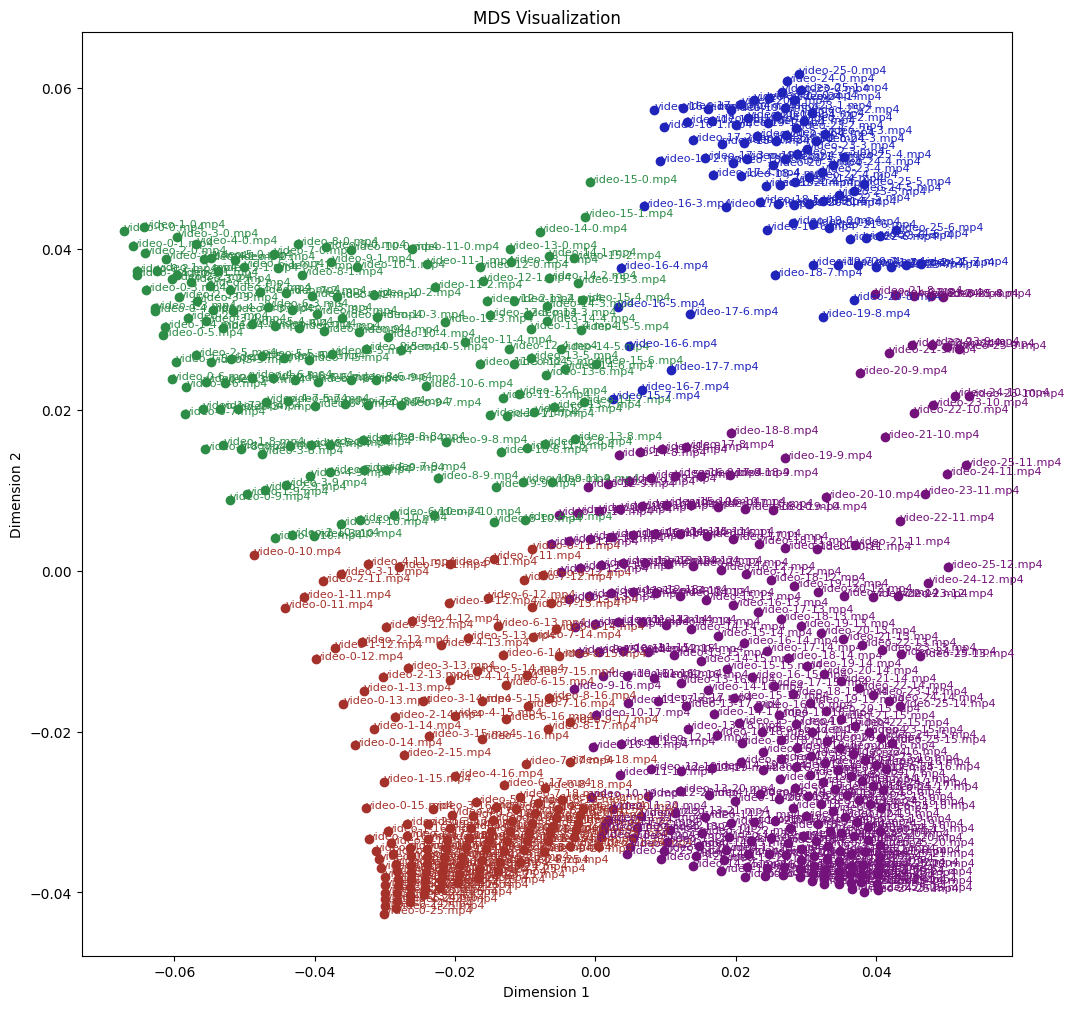

In [8]:
def mds_vis(r, names, clrs, drc, d, dr):
    # ==> compute MDS
    mds = MDS(n_components=d, dissimilarity='precomputed', random_state=0)
    proj = embedding = mds.fit_transform(r)

    # ==> save r and mds projection coordinates
    np.save(dr + 'sm.npy', r)
    np.save(dr + 'mds.npy', proj)
    np.save(dr + 'labels.npy', names)
    # ==> matlab format
    mdic = {"proj": proj, "sm": r, "labels": names}
    savemat(dr + 'sm.mat', mdic)
    
    #==> plot
    if d == 2:
        fig = plt.figure(figsize=(12, 12))
        for k in range(len(names)):
            plt.scatter(proj[k,0],proj[k,1], c=clrs[k]/255)
            plt.text(proj[k, 0], proj[k, 1], names[k],c=clrs[k]/255, size=8)
        plt.title("MDS Visualization")
        plt.xlabel("Dimension 1")
        plt.ylabel("Dimension 2")
        plt.savefig(drc + 'plot.png')
        plt.show()
    if d == 3:
        fig = plt.figure(figsize=(12, 12))
        ax = fig.add_subplot(111, projection='3d')
        for k in range(len(names)):
            ax.scatter3D(proj[k,0], proj[k,1], proj[k,2], c=clrs[k]/255)
            ax.text(proj[k, 0], proj[k, 1], proj[k,2], names[k],c=clrs[k]/255, size=8)
        plt.title("MDS Visualization")
        plt.xlabel("Dimension 1")
        plt.ylabel("Dimension 2")
        plt.savefig(drc + 'plot.png')
        plt.show()

    return fig

# ==========================================================================================================================
    
# ==> read in some features
# ==> load ctx matrix of z columns for each motion in the spectra mosaic
bs_dr = '/home/thomas/Desktop/MIT-projects/meta-motivo-features/data/'
drf = '/home/thomas/Desktop/MIT-projects/meta-motivo-features/' #'/media/thomas/U/metamotivo-features/'

# ==> list of file names
names = []
# ==> track RGB colors for visualization
clrs  = []

# ==> initialize feature matrices
CoT_ctx_m = np.zeros((len(alphas)*len(alphas),1))
travel_ctx_m = np.zeros((len(alphas)*len(alphas),1))

qvel_traj_m = np.zeros(( len(alphas)*len(alphas), 3075 ))
qpos_traj_m = np.zeros(( len(alphas)*len(alphas), 3116 ))

k = 0
for i in range(0,len(alphas)):
    for j in range(0,len(alphas)):

        CoT_ctx = np.load(drf + 'features/' + 'CoT_ctx-'  + str(i) + '-' + str(j) +  '.npy')
        travel_ctx = np.load(drf + 'features/' + 'travel_ctx-'  + str(i) + '-' + str(j) +  '.npy')

        qvel_traj = np.load(drf + 'features/' + 'qvel_traj_ctx-'  + str(i) + '-' + str(j) +  '.npy')
        qpos_traj = np.load(drf + 'features/' + 'qpos_traj_ctx-'  + str(i) + '-' + str(j) +  '.npy')

        # ==> store
        CoT_ctx_m[k,:] = CoT_ctx
        travel_ctx_m[k,:] = travel_ctx

        qvel_traj_m[k,:] = qvel_traj.flatten()
        qpos_traj_m[k,:] = qpos_traj.flatten()
        
        # ==> file names (mp4)
        names.append('video-' + str(i) + '-' + str(j) + '.mp4')

        # ==> partition - get column index of max probability in q(m|w)
        rgb_idx_p = np.argmax(qmw,1)
        # ==> reshape color matrix cm in partition corresponding to max probability in q(m|w)
        cm_p = np.reshape(np.squeeze(cm[:,rgb_idx_p[k],:]),(26,26,3))
        
        # ==> colors for vis
        clrs.append(cm_p[i,j,:])
        
        k += 1
        # ==> update
        # print('done loading features for all time frames in ctx for motion ' + str(i) + ', ' + str(j))

# ==> feature matrix
# F  = np.concatenate(( CoT_ctx_m/np.max(CoT_ctx_m), travel_ctx_m/np.max(travel_ctx_m) ),1)
# F = qvel_traj_m
F = qpos_traj_m
r = 1 - np.corrcoef(F)

# # # ==> cross-corr matrix convert to dissimilarity
# plt.figure(figsize=(12, 12))
# plt.imshow(r)
# plt.show()

# dimensionality of mds embedding
DIM = 2
# ==> MDS
fig = mds_vis(r, names, clrs, drc, DIM, bs_dr)